Change C_s_n_0 from 28544 -> 28800, need to change below 28540, to avoid first step error at Home PC
CV from C/20 -> C/50  
change pos critical stress to 2e9, to reduce LAM_pos and associtaed LLI

Refumulate ageing process to incoorpate dry-out  241020

In [18]:
# Load modules
import pybamm as pb;import pandas as pd;import numpy as np;
import os, json,openpyxl,traceback,multiprocessing,scipy.optimize,sys
import matplotlib.pyplot as plt;
import pickle,imageio,timeit,random,time, signal
from scipy.io import savemat,loadmat;
from pybamm import constants,exp;import matplotlib as mpl

# Global setting 
purpose_i = "Warwick_1129_n10p20_ncs10pcs10_Dint3e-18_ncr0.01_decay1e-6_pordecay0.5_solver_save"
rows_per_file = 1  
Scan_end_end = 12

# define options:
On_HPC =  False;        Runshort="War";    Add_Rest = False
Plot_Exp=True;          Timeout=False; ## revised 1129   
Return_Sol=True;   
Check_Small_Time=True;  R_from_GITT = False
fs = 14; dpi = 300; Re_No =0
Options = [ 
    On_HPC,Runshort,Add_Rest,
    Plot_Exp,Timeout,Return_Sol,
    Check_Small_Time,R_from_GITT,
    dpi,fs]
Timelimit = int(3600*12) # give 12 hours!

# Add path to system to ensure Fun_P2 can be used
if On_HPC:
    i_bundle = int(os.environ["PBS_ARRAY_INDEX"])
else:
    i_bundle = 5; 
Scan_start = (i_bundle-1)*rows_per_file+1;    
Scan_end   = min(Scan_start + rows_per_file-1, Scan_end_end)    
purpose = f"{purpose_i}_Case_{Scan_start}_{Scan_end}"
Target  = f'/{purpose}/'
# interpetation: Simnon suggested, with cracking activation, heat transfer
para_csv = f"Bundle_{i_bundle}.csv"  # name of the random file to get parameters

# Path setting:
if On_HPC:                          # Run on HPC
    Path_csv = f"InputData/{purpose_i}/" 
    Path_Input = "InputData/" 
    BasicPath=os.getcwd() 
    Para_file = Path_csv +  para_csv
else:
    # Add path to system to ensure Fun_P2 can be used
    import sys  
    str_path_0 = os.path.abspath(os.path.join(pb.__path__[0],'..'))
    str_path_1 = os.path.abspath(
        os.path.join(str_path_0,"./PyBaMM.worktrees/origin-Latest_pub_pybamm/docs/source/examples/notebooks/Xinlei"))
    sys.path.append(str_path_1) 
    Path_Input = os.path.expanduser(
       "~/PyBaMM.worktrees/origin-Latest_pub_pybamm/docs/source/examples/notebooks/Xinlei/Get_Random_sets") # for Linux
    BasicPath =  os.path.expanduser(
       "~/PyBaMM.worktrees/origin-Latest_pub_pybamm/docs/source/examples/notebooks/Xinlei/Get_Random_sets")
    # Para_file = Path_Input+f'{purpose_i}/'+para_csv
    Para_file = Path_Input+f'/{purpose_i}.csv'


# import all functions 
from Fun_NC_Xinlei_solver_1129_saveage import *  ## change solver 1020

# Load input file
Para_dict_list = load_combinations_from_csv(Para_file)
pool_no = len(Para_dict_list) # do parallel computing if needed

midc_merge_all = [];  Sol_RPT_all = [];  Sol_AGE_all = []
Path_List = [BasicPath, Path_Input,Target,purpose] 

if Re_No == 0:
    midc_merge,Sol_RPT,Sol_AGE,DeBug_Lists = Run_P2_Excel (
        Para_dict_list[0], Path_List, 
        Re_No, Timelimit, Options) 
elif Re_No > 0:
    pass


## 需要调整RPT中的step号 match新的RPT done, 并且修改def Get_Output_Keys(Para_dict_i)中的soldict done
## 需要调整SoH初始值，以及cracking
## 为什么孔隙率增加了？或者是pore增大了 241022 run 100 cyc to see, change overwrite problem
## 241024 发现SEI模型实际上用的还是不分正负极的参数？所以overwrite还是不分正负极，但为什么后处理要加negative???
## 241025 加了一个1C SOH作为对模型的SOH
## 241030 dry-out和不加dryout case对比，加了dry-out以后74圈死亡，算不出来，改变crack试一下
## 241030 需要把FUN_NC_Xinlei中的degradation variable (cell thickness?) 每圈都提取出来，用来计算压力，但还是首先提取容量




总扫描案例数为 1
Start Now! Scan 0 Re 0
Exp: 10
T: 25
Aging T is 25degC
1.236252930713571e-08 0.2223931640762495
Has Overwritten Initial outer SEI thickness [m] to be 1.49e-08 and Negative electrode porosity to be 0.222 to account for initial capacity loss of 0.135 Ah
Scan 0 Re 0: DryOut = On
Initial electrolyte amount is  5.1261572813937475 mL
Scan 0 Re 0: Spent 1.756 ms on Initialization

Succeed to run break in for the 0th time with capacity increase of 0Ah and perturbation of 0.00e+00Ah

Scan 0 Re 0: Finish break-in cycle within 47.677 s
Scan 0 Re 0: Finish post-process for break-in cycle within 234.567 ms
Succeed to run the ageing set for 20 cycles the 1th time
Scan 0 Re 0: Finish for No.0 ageing cycles within 4 minutes, 2 seconds
Scan 0 Re 0: Finish post-process for No.20 ageing cycles within 346.937 ms
Succeed to run RPT for the 1th time
Scan 0 Re 0: Finish for No.20 RPT cycles within 47.193 s
Scan 0 Re 0: Finish post-process for No.20 RPT cycles within 172.567 ms
Succeed to run the ag

In [20]:
# define list to output variables
Output_list = ["Positive electrode thickness change [m]","Negative electrode thickness change [m]",
               "Cell thickness change [m]","Positive electrode thickness change [m]","Negative electrode thickness change [m]",
               
               "Loss of lithium to negative SEI [mol]","Loss of lithium to negative SEI on cracks [mol]",
               "Loss of capacity to negative SEI [A.h]","Loss of capacity to negative SEI on cracks [A.h]",
               "Loss of lithium to negative lithium plating [mol]",
               "Loss of capacity to negative lithium plating [A.h]",
               "Total capacity lost to side reactions [A.h]",
       
               "Total lithium lost [mol]",
               "Loss of lithium due to loss of active material in negative electrode [mol]",
               "Loss of lithium due to loss of active material in positive electrode [mol]",
             
               "Loss of lithium inventory [%]",
               "Loss of active material in negative electrode [%]","Loss of active material in positive electrode [%]",
               
               # SEI
               'X-averaged negative inner SEI thickness [m]','X-averaged negative outer SEI thickness [m]',
               'X-averaged negative SEI thickness [m]','X-averaged negative total SEI thickness [m]',

               # Plating
               'X-averaged negative  lithium plating thickness [m]','X-averaged negative dead lithium thickness [m]',

               #"Terminal voltage [V]","Time [h]", "Time [min]", "Time [s]",
               "X-averaged cell temperature [C]",
               "Throughput capacity [A.h]",
               ]

In [70]:
import pickle
for i in range(0, len(Sol_AGE)):
    Sol_AGE[i].save_data(BasicPath + Target+ "Mats/" + f"data_{i}th.pkl",Output_list)

In [2]:
import pickle
# Load modules
import pybamm as pb;import pandas as pd;import numpy as np;
import os, json,openpyxl,traceback,multiprocessing,scipy.optimize,sys
import matplotlib.pyplot as plt;
import pickle,imageio,timeit,random,time, signal
from scipy.io import savemat,loadmat;
from pybamm import constants,exp;import matplotlib as mpl

# Global setting 
purpose_i = "Warwick_1129_n10p20_ncs10pcs10_Dint3e-18_ncr0.01_decay1e-6_pordecay0.5_solver_save"
rows_per_file = 1  
Scan_end_end = 12

# define options:
On_HPC =  False;        Runshort="War";    Add_Rest = False
Plot_Exp=True;          Timeout=False; ## revised 1129   
Return_Sol=True;   
Check_Small_Time=True;  R_from_GITT = False
fs = 14; dpi = 300; Re_No =0
Options = [ 
    On_HPC,Runshort,Add_Rest,
    Plot_Exp,Timeout,Return_Sol,
    Check_Small_Time,R_from_GITT,
    dpi,fs]
Timelimit = int(3600*12) # give 12 hours!

# Add path to system to ensure Fun_P2 can be used
if On_HPC:
    i_bundle = int(os.environ["PBS_ARRAY_INDEX"])
else:
    i_bundle = 5; 
Scan_start = (i_bundle-1)*rows_per_file+1;    
Scan_end   = min(Scan_start + rows_per_file-1, Scan_end_end)    
purpose = f"{purpose_i}_Case_{Scan_start}_{Scan_end}"
Target  = f'/{purpose}/'
# interpetation: Simnon suggested, with cracking activation, heat transfer
para_csv = f"Bundle_{i_bundle}.csv"  # name of the random file to get parameters

# Path setting:
if On_HPC:                          # Run on HPC
    Path_csv = f"InputData/{purpose_i}/" 
    Path_Input = "InputData/" 
    BasicPath=os.getcwd() 
    Para_file = Path_csv +  para_csv
else:
    # Add path to system to ensure Fun_P2 can be used
    import sys  
    str_path_0 = os.path.abspath(os.path.join(pb.__path__[0],'..'))
    str_path_1 = os.path.abspath(
        os.path.join(str_path_0,"./PyBaMM.worktrees/origin-Latest_pub_pybamm/docs/source/examples/notebooks/Xinlei"))
    sys.path.append(str_path_1) 
    Path_Input = os.path.expanduser(
       "~/PyBaMM.worktrees/origin-Latest_pub_pybamm/docs/source/examples/notebooks/Xinlei/Get_Random_sets") # for Linux
    BasicPath =  os.path.expanduser(
       "~/PyBaMM.worktrees/origin-Latest_pub_pybamm/docs/source/examples/notebooks/Xinlei/Get_Random_sets")
    # Para_file = Path_Input+f'{purpose_i}/'+para_csv
    Para_file = Path_Input+f'/{purpose_i}.csv'


# import all functions 
from Fun_NC_Xinlei_solver_1129_saveage import *  ## change solver 1020


with open(BasicPath + Target+ "Mats/" +"data_4th.pkl", "rb") as file:
    data = pickle.load(file)
data

{'Positive electrode thickness change [m]': array([-1.53758045e-08, -1.53724216e-08, -1.53698892e-08, ...,
        -9.94483059e-09, -1.04172641e-08, -1.08127267e-08]),
 'Negative electrode thickness change [m]': array([-7.70338188e-09, -7.71623609e-09, -7.72585819e-09, ...,
         7.33144810e-08,  7.39824095e-08,  7.43921043e-08]),
 'Cell thickness change [m]': array([-2.32443757e-08, -2.32226603e-08, -2.32063968e-08, ...,
         1.06455124e-06,  1.04160715e-06,  1.02125906e-06]),
 'Loss of lithium to negative SEI [mol]': array([0.00031377, 0.00031377, 0.00031377, ..., 0.00036471, 0.00036471,
        0.00036472]),
 'Loss of lithium to negative SEI on cracks [mol]': array([0.00123061, 0.00123061, 0.00123061, ..., 0.00135375, 0.00135376,
        0.00135378]),
 'Loss of capacity to negative SEI [A.h]': array([0.00840941, 0.00840941, 0.00840941, ..., 0.00977471, 0.00977489,
        0.00977505]),
 'Loss of capacity to negative SEI on cracks [A.h]': array([0.03298206, 0.03298206, 0.03298

In [78]:

import pickle
with open(BasicPath + Target+ "Mats/" +"0_Re_0-midc_merge.pkl", "rb") as file:
    data1 = pickle.load(file)
data1

[{'x [m]': [8.52e-06,
   2.556e-05,
   4.26e-05,
   5.964e-05,
   7.668e-05,
   8.64e-05,
   8.88e-05,
   9.12e-05,
   9.36e-05,
   9.6e-05,
   0.00010476,
   0.00011988000000000001,
   0.00013500000000000003,
   0.00015012,
   0.00016523999999999998],
  'x_n [m]': [8.52e-06, 2.556e-05, 4.26e-05, 5.964e-05, 7.668e-05],
  'x_s [m]': [8.64e-05, 8.88e-05, 9.12e-05, 9.36e-05, 9.6e-05],
  'x_p [m]': [0.00010476,
   0.00011988000000000001,
   0.00013500000000000003,
   0.00015012,
   0.00016523999999999998],
  'CCend Porosity': [[0.22125993438395306,
    0.22120912387872596,
    0.2210807961098157,
    0.22081339295480262,
    0.2202255265417765,
    0.47,
    0.47,
    0.47,
    0.47,
    0.47,
    0.34068020766562673,
    0.3406802081760219,
    0.3406802085064765,
    0.3406802086949031,
    0.3406802087675807],
   [0.2185531760934863,
    0.21842603648906586,
    0.21812746178061126,
    0.2175550472063869,
    0.21645531936794143,
    0.47,
    0.47,
    0.47,
    0.47,
    0.47,
    0.

In [24]:
Path_pkl

'/home/xinlei/PyBaMM.worktrees/origin-Latest_pub_pybamm/docs/source/examples/notebooks/Xinlei/Get_Random_sets/Warwick_1125_n10p20_ncs10pcs10_Dint3e-18_ncr0.01_decay1e-6_pordecay0.5_solver_Case_5_5/Mats/0_Re_0-midc_merge.pkl'

In [79]:
# 从sol中计算循环过程中的容量，需要调整step如果换了工步
def calculate_capacities(sol):
    # 初始化充电容量和放电容量列表
    charge_capacities = []
    discharge_capacities = []

    # 遍历sol数据结构中的每个循环
    for cycle in sol.cycles:
        # 获取第一个步骤的放电容量时间序列
        step1_times = cycle.steps[0]["Discharge capacity [A.h]"].entries
        # 获取第二个步骤的放电容量时间序列
        step2_times = cycle.steps[1]["Discharge capacity [A.h]"].entries
        # 获取第三个步骤的放电容量时间序列
        step3_times = cycle.steps[2]["Discharge capacity [A.h]"].entries

        # 计算第一个步骤的初始值和第二个步骤的最后值的差（充电容量）
        charge_capacity = step2_times[-1] - step1_times[0]
        charge_capacities.append((-1) * charge_capacity)
        
        # 计算第三步的初始值和最后值的差（放电容量）
        discharge_capacity = step3_times[-1] - step3_times[0]
        discharge_capacities.append(discharge_capacity)

    # 返回计算结果
    return charge_capacities, discharge_capacities

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
cwd = os.getcwd()


# 读取 pickle 文件
#pickle_file_path = cwd + '/docs/source/examples/notebooks/models/exp_LG/processed_data.pkl'
pickle_file_path = cwd + '/exp_LG/processed_data.pkl'
cycles_df = pd.read_pickle(pickle_file_path)
print("DataFrame loaded from pickle file")
print(cycles_df.head())


# 提取每个循环的最后一个 Q_dis 和 Q_cha 非零值
summary_data = []

for cycle in cycles_df.index.levels[0]:
    cycle_data = cycles_df.loc[cycle]
    last_q_dis = cycle_data[cycle_data['Q_dis'] > 0]['Q_dis'].iloc[-1] if not cycle_data[cycle_data['Q_dis'] > 0].empty else 0
    last_q_cha = cycle_data[cycle_data['Q_cha'] > 0]['Q_cha'].iloc[-1] if not cycle_data[cycle_data['Q_cha'] > 0].empty else 0
    summary_data.append([cycle, last_q_cha, last_q_dis])

# 创建一个新的 DataFrame 存储结果
summary_df = pd.DataFrame(summary_data, columns=['Cycle', 'Last_Q_cha', 'Last_Q_dis'])




DataFrame loaded from pickle file
            Mode  RelativeTime   Voltage          I  Q_dis     Q_cha  \
Cycle Step                                                             
1     1      1.0        0.0000  2.680430  1407.8055    0.0  0.000078   
      2      1.0        0.0084  2.690530  1574.4427    0.0  0.003691   
      3      1.0        0.0294  2.700598  1640.2499    0.0  0.013108   
      4      1.0        0.0634  2.710643  1664.4644    0.0  0.028749   
      5      1.0        0.1074  2.720645  1668.5892    0.0  0.049123   

                 Cap         R    Pressure  Temperature  
Cycle Step                                               
1     1     0.000078  1.903978  159.026607      25.3794  
      2     0.003691  1.708878  158.944819      25.3885  
      3     0.013108  1.646455  158.998347      25.4014  
      4     0.028749  1.628537  159.049016      25.4088  
      5     0.049123  1.630506  158.990980      25.4014  


In [82]:
model_RPT = model.set_initial_conditions_from(sol)
exp_RPT = pybamm.Experiment(
    [
        "Hold at 2.5 V for 1 hours",
        "Charge at 0.1C until 4.2 V",
        "Hold at 4.2 V until C/20",
        "Discharge at 0.1C until 2.5 V",
    ]
)

sim_RPT = pybamm.Simulation(model_RPT, parameter_values=param, experiment=exp_RPT, var_pts=var_pts )
sol_RPT_1 = sim_RPT.solve() 

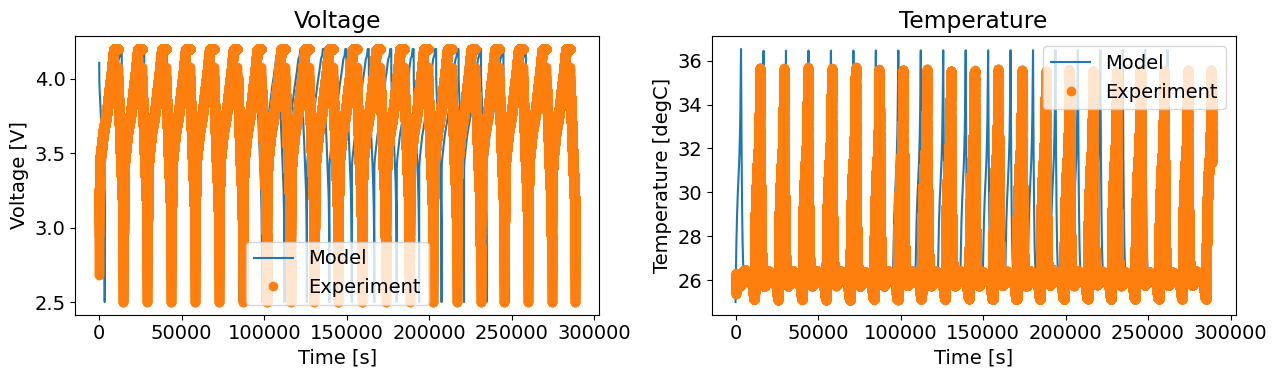

In [26]:
# 假设 `cycles_df` 是一个字典，其中的键是循环编号，每个键对应的值是包含该循环数据的DataFrame。

# 初始化空的DataFrame来存储合并后的电压和温度数据
merged_voltage = pd.DataFrame()
merged_temperature = pd.DataFrame()

# 初始化空的DataFrame来存储合并后的相对时间
merged_cycles_time = pd.DataFrame()

# 基准时间，从第一个循环的第一个数据点开始
base_time = cycles_df.loc[1]["RelativeTime"].iloc[0]

# 合并前20个循环
for i in range(1, 21):
    # 调整时间以基于第一个循环的起始时间
    adjusted_time = cycles_df.loc[i]["RelativeTime"] - base_time
    
    # 将调整后的时间添加到时间DataFrame中
    merged_cycles_time = pd.concat([merged_cycles_time, adjusted_time], ignore_index=True)
    
    # 将电压数据添加到电压DataFrame中
    merged_voltage = pd.concat([merged_voltage, cycles_df.loc[i]["Voltage"]], ignore_index=True)
    
    # 将温度数据添加到温度DataFrame中
    merged_temperature = pd.concat([merged_temperature, cycles_df.loc[i]["Temperature"]], ignore_index=True)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# plot the 1C results
t_sol = Sol_AGE[0]["Time [s]"].entries

ax1.plot(t_sol, Sol_AGE[0]["Voltage [V]"](t_sol))
ax1.plot(merged_cycles_time, merged_voltage, "o")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.set_title("Voltage")
ax1.legend(["Model", "Experiment"], loc="best")

ax2.plot(t_sol, Sol_AGE[0]["X-averaged cell temperature [C]"](t_sol))
ax2.plot(merged_cycles_time, merged_temperature, "o")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Temperature [degC]")
ax2.set_title("Temperature")
ax2.legend(["Model", "Experiment"], loc="best")

plt.tight_layout()
plt.show()

105

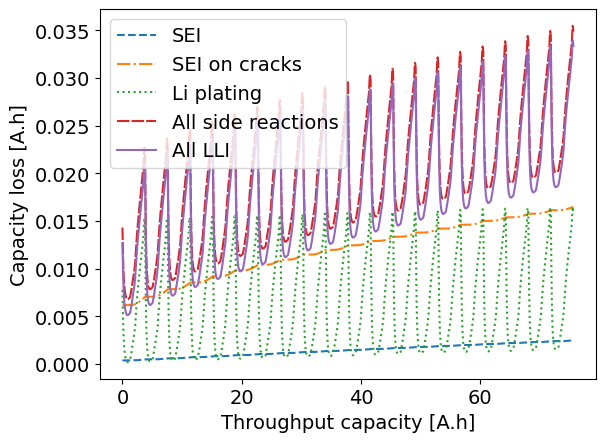

In [89]:
Qt = Sol_AGE[0]["Time [h]"].entries
Q_SEI = Sol_AGE[0]["Loss of capacity to negative SEI [A.h]"].entries
Q_SEI_cr = Sol_AGE[0]["Loss of capacity to negative SEI on cracks [A.h]"].entries
Q_plating = Sol_AGE[0]["Loss of capacity to negative lithium plating [A.h]"].entries
Q_side = Sol_AGE[0]["Total capacity lost to side reactions [A.h]"].entries

#Q_particle = sol["Total lithium lost from particles [mol]"].entries * 96485.3 / 3600

Q_LLI = (
    Sol_AGE[0]["Total lithium lost [mol]"].entries * 96485.3 / 3600
)  # convert from mol to A.h

plt.figure()
plt.plot(Qt, Q_SEI, label="SEI", linestyle="dashed")
plt.plot(Qt, Q_SEI_cr, label="SEI on cracks", linestyle="dashdot")
plt.plot(Qt, Q_plating, label="Li plating", linestyle="dotted")
plt.plot(Qt, Q_side, label="All side reactions", linestyle=(0, (6, 1)))
#plt.plot(Qt,Q_particle,label = "Particle")
plt.plot(Qt, Q_LLI, label="All LLI")
plt.xlabel("Throughput capacity [A.h]")
#plt.xlim(0,25)
plt.ylabel("Capacity loss [A.h]")
#plt.ylim(0,0.03)
plt.legend()
plt.show()

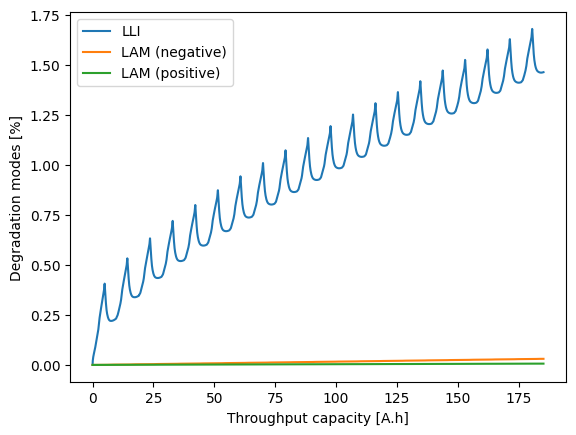

In [90]:
Qt = sol["Throughput capacity [A.h]"].entries
LLI = sol["Loss of lithium inventory [%]"].entries
LAM_neg = sol["Loss of active material in negative electrode [%]"].entries
LAM_pos = sol["Loss of active material in positive electrode [%]"].entries
plt.figure()
plt.plot(Qt, LLI, label="LLI")
plt.plot(Qt, LAM_neg, label="LAM (negative)")
plt.plot(Qt, LAM_pos, label="LAM (positive)")
plt.xlabel("Throughput capacity [A.h]")
plt.ylabel("Degradation modes [%]")
plt.legend()
plt.show()

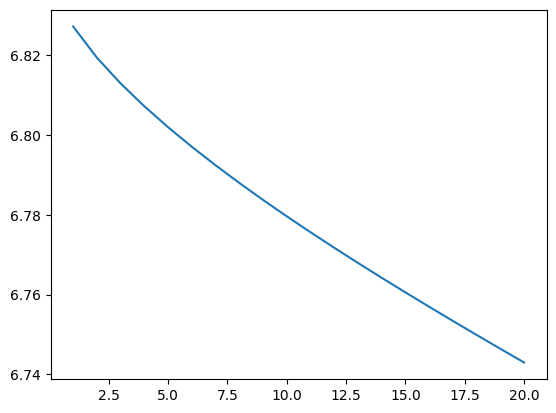

In [91]:
plt.plot(sol.summary_variables["Cycle number"],sol.summary_variables["Cyclable lithium capacity [A.h]"])


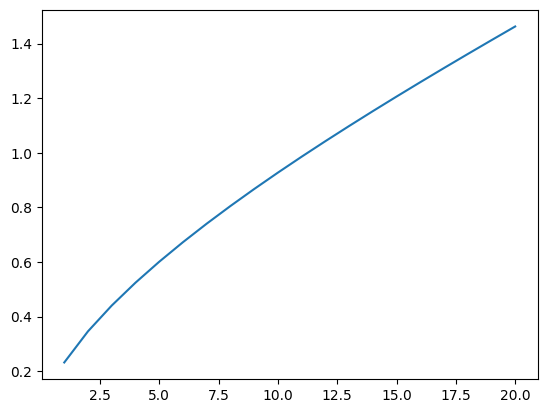

In [92]:
plt.plot(sol.summary_variables["Cycle number"],sol.summary_variables["Loss of lithium inventory [%]"])

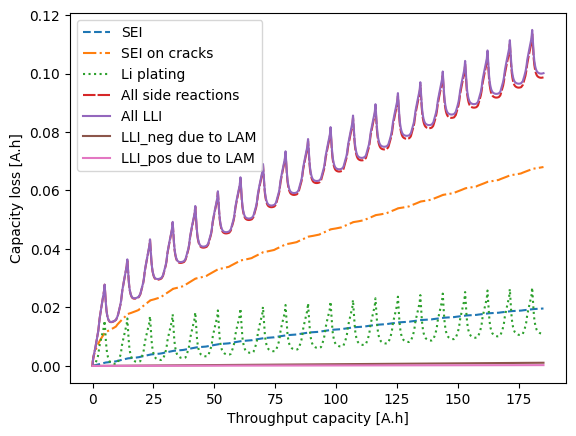

In [93]:
Qt = sol["Throughput capacity [A.h]"].entries
Q_SEI = sol["Loss of capacity to negative SEI [A.h]"].entries
Q_SEI_cr = sol["Loss of capacity to negative SEI on cracks [A.h]"].entries
Q_plating = sol["Loss of capacity to negative lithium plating [A.h]"].entries
Q_side = sol["Total capacity lost to side reactions [A.h]"].entries
Q_LLI = (
    sol["Total lithium lost [mol]"].entries * 96485.3 / 3600
)  # convert from mol to A.h

Q_LLI_due2_LAM_neg = (
    sol["Loss of lithium due to loss of active material in negative electrode [mol]"].entries * 96485.3 / 3600
)
Q_LLI_due2_LAM_pos = (
    sol["Loss of lithium due to loss of active material in positive electrode [mol]"].entries * 96485.3 / 3600
)
plt.figure()
plt.plot(Qt, Q_SEI, label="SEI", linestyle="dashed")
plt.plot(Qt, Q_SEI_cr, label="SEI on cracks", linestyle="dashdot")
plt.plot(Qt, Q_plating, label="Li plating", linestyle="dotted")
plt.plot(Qt, Q_side, label="All side reactions", linestyle=(0, (6, 1)))
plt.plot(Qt, Q_LLI, label="All LLI")
plt.plot(Qt, Q_LLI_due2_LAM_neg, label="LLI_neg due to LAM")
plt.plot(Qt, Q_LLI_due2_LAM_pos, label="LLI_pos due to LAM")
plt.xlabel("Throughput capacity [A.h]")
plt.ylabel("Capacity loss [A.h]")
plt.legend()
plt.show()

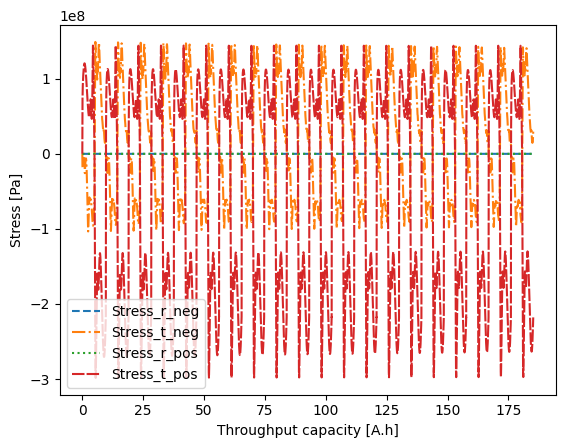

In [94]:
Qt = sol["Throughput capacity [A.h]"].entries
Stress_r_neg = sol["X-averaged negative particle surface radial stress [Pa]"].entries
Stress_t_neg = sol["X-averaged negative particle surface tangential stress [Pa]"].entries
Stress_r_pos = sol["X-averaged positive particle surface radial stress [Pa]"].entries
Stress_t_pos = sol["X-averaged positive particle surface tangential stress [Pa]"].entries
plt.figure()
plt.plot(Qt, Stress_r_neg, label="Stress_r_neg", linestyle="dashed")
plt.plot(Qt, Stress_t_neg, label="Stress_t_neg", linestyle="dashdot")
plt.plot(Qt, Stress_r_pos, label="Stress_r_pos", linestyle="dotted")
plt.plot(Qt, Stress_t_pos, label="Stress_t_pos", linestyle=(0, (6, 1)))

plt.xlabel("Throughput capacity [A.h]")
plt.ylabel("Stress [Pa]")
plt.legend()
plt.show()